In [1]:
!gdown 1ua30qTwUOYkAPig8KQdb3vZLn5r-Dgu_

Downloading...
From: https://drive.google.com/uc?id=1ua30qTwUOYkAPig8KQdb3vZLn5r-Dgu_
To: /content/uncond.csv
100% 45.5k/45.5k [00:00<00:00, 60.7MB/s]


In [2]:
!pip install -q rdkit moses

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 51.7 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import QED
from rdkit.Chem import RDConfig
import os, sys
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer
from rdkit.Chem import FilterCatalog

In [71]:
df = pd.read_csv("/content/uncond.csv", header=None, names=["SMILES"])
df

,SMILES
0,COCc1c(C(=O)N(CC(C)C)CC(C)C)cnn1-c1ccccc1
1,CCCCCCNCCC1CN(C(=O)C2CN3CCC2CC3)CC1C
2,COc1ccc2c(C)cc(N3CCc4nnc(Cn5cccc5)n4CC3)nc2c1
3,CC1C(NCCOc2ccc(NC(=O)CCOc3ccc(Cl)cc3)cc2N)CC2C...
4,COc1cc(Oc2ccccc2)ccc1NC(=O)C(C)NC1CC1
...,...
995,COc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(Oc3ccnc...
996,Cc1cccc2c(=O)n(CCC(=O)NC3CC3C3CC3C)cnc12
997,COCC1(C(=O)NC2CCCN(C(=O)C=Cc3ccc[nH]3)C2)CCC1
998,Cc1cccc(C(=O)N2CCC(CNC(=O)C3CC3c3ccncc3)C2)n1


# 1. Отбор валидных молекул

Из 1000 сгенерированных 2 молекулы оказались невалидными

In [72]:
valid_df = df[df["SMILES"].apply(lambda x: Chem.MolFromSmiles(x) is not None)]
valid_df

[09:26:42] Can't kekulize mol.  Unkekulized atoms: 13 14 19 20 21 23 24 32 33 34 35 36 37 38 39
[09:26:42] Can't kekulize mol.  Unkekulized atoms: 32 33 34 73 74 76 77


,SMILES
0,COCc1c(C(=O)N(CC(C)C)CC(C)C)cnn1-c1ccccc1
1,CCCCCCNCCC1CN(C(=O)C2CN3CCC2CC3)CC1C
2,COc1ccc2c(C)cc(N3CCc4nnc(Cn5cccc5)n4CC3)nc2c1
3,CC1C(NCCOc2ccc(NC(=O)CCOc3ccc(Cl)cc3)cc2N)CC2C...
4,COc1cc(Oc2ccccc2)ccc1NC(=O)C(C)NC1CC1
...,...
995,COc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(Oc3ccnc...
996,Cc1cccc2c(=O)n(CCC(=O)NC3CC3C3CC3C)cnc12
997,COCC1(C(=O)NC2CCCN(C(=O)C=Cc3ccc[nH]3)C2)CCC1
998,Cc1cccc(C(=O)N2CCC(CNC(=O)C3CC3c3ccncc3)C2)n1


In [73]:
valid_df["MOL"] = list(map(Chem.MolFromSmiles, valid_df["SMILES"].tolist()))

# Тосичность

In [74]:
params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.BRENK)
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.ZINC)
catalog = FilterCatalog.FilterCatalog(params)

In [75]:
valid_df["TOXITY"] = list(map(catalog.HasMatch, valid_df["MOL"].tolist()))
valid_df["TOXITY_SOURCE"] = list(map(lambda x: catalog.GetFirstMatch(x).GetDescription() if catalog.HasMatch(x) else None, valid_df["MOL"].tolist()))

In [76]:
valid_df.head(5)

,SMILES,MOL,TOXITY,TOXITY_SOURCE
0,COCc1c(C(=O)N(CC(C)C)CC(C)C)cnn1-c1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x794dea03a0a0>,False,None
1,CCCCCCNCCC1CN(C(=O)C2CN3CCC2CC3)CC1C,<rdkit.Chem.rdchem.Mol object at 0x794dea03a030>,True,Aliphatic_long_chain
2,COc1ccc2c(C)cc(N3CCc4nnc(Cn5cccc5)n4CC3)nc2c1,<rdkit.Chem.rdchem.Mol object at 0x794dea03aab0>,False,None
3,CC1C(NCCOc2ccc(NC(=O)CCOc3ccc(Cl)cc3)cc2N)CC2C...,<rdkit.Chem.rdchem.Mol object at 0x794dea039fc0>,True,Aliphatic_long_chain
4,COc1cc(Oc2ccccc2)ccc1NC(=O)C(C)NC1CC1,<rdkit.Chem.rdchem.Mol object at 0x794dea03a810>,False,None


678 - Осталось после проверки на токсичность

In [77]:
valid_df = valid_df[valid_df['TOXITY'] == False][["SMILES", "MOL"]]
valid_df

,SMILES,MOL
0,COCc1c(C(=O)N(CC(C)C)CC(C)C)cnn1-c1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x794dea03a0a0>
2,COc1ccc2c(C)cc(N3CCc4nnc(Cn5cccc5)n4CC3)nc2c1,<rdkit.Chem.rdchem.Mol object at 0x794dea03aab0>
4,COc1cc(Oc2ccccc2)ccc1NC(=O)C(C)NC1CC1,<rdkit.Chem.rdchem.Mol object at 0x794dea03a810>
6,COC(=O)C(Nc1ccc(NC(=O)Cc2c[nH]c3ccccc23)nc1)C(C)C,<rdkit.Chem.rdchem.Mol object at 0x794dea03a110>
8,O=C(COc1cccnc1)NC(c1ccccc1)c1ccc2nc[nH]c2c1,<rdkit.Chem.rdchem.Mol object at 0x794dea03a1f0>
...,...,...
992,COc1cccc(S(=O)(=O)NC2(c3ccccn3)CC2)c1,<rdkit.Chem.rdchem.Mol object at 0x794dea065460>
993,CCOc1cncc(C(=O)n2cc(CN)cnc2=N)n1,<rdkit.Chem.rdchem.Mol object at 0x794dea0654d0>
996,Cc1cccc2c(=O)n(CCC(=O)NC3CC3C3CC3C)cnc12,<rdkit.Chem.rdchem.Mol object at 0x794dea065620>
998,Cc1cccc(C(=O)N2CCC(CNC(=O)C3CC3c3ccncc3)C2)n1,<rdkit.Chem.rdchem.Mol object at 0x794dea065700>


# Оценка свойств

In [78]:
from rdkit.Chem import Descriptors, rdMolDescriptors

## Дескрипторы

In [79]:
valid_df["WA"] = list(map(Descriptors.MolWt, valid_df["MOL"].tolist()))
valid_df["HA"] = list(map(lambda x: x.GetNumHeavyAtoms(), valid_df["MOL"].tolist()))
valid_df["LogP"] = list(map(Descriptors.MolLogP, valid_df["MOL"].tolist()))
valid_df["PSA"] = list(map(Descriptors.TPSA, valid_df["MOL"].tolist()))
valid_df["HBA"] = list(map(Descriptors.NumHAcceptors, valid_df["MOL"].tolist()))
valid_df["HBD"] = list(map(Descriptors.NumHDonors, valid_df["MOL"].tolist()))
valid_df["Fsp3"] = list(map(Descriptors.NumHDonors, valid_df["MOL"].tolist()))
valid_df["nRotB"] = list(map(Descriptors.NumRotatableBonds, valid_df["MOL"].tolist()))

In [80]:
valid_df

,SMILES,MOL,WA,HA,LogP,PSA,HBA,HBD,Fsp3,nRotB
0,COCc1c(C(=O)N(CC(C)C)CC(C)C)cnn1-c1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x794dea03a0a0>,343.471,25,3.77290,47.36,3,0,0,8
2,COc1ccc2c(C)cc(N3CCc4nnc(Cn5cccc5)n4CC3)nc2c1,<rdkit.Chem.rdchem.Mol object at 0x794dea03aab0>,388.475,29,3.05582,61.00,5,0,0,4
4,COc1cc(Oc2ccccc2)ccc1NC(=O)C(C)NC1CC1,<rdkit.Chem.rdchem.Mol object at 0x794dea03a810>,326.396,24,3.56650,59.59,4,2,2,7
6,COC(=O)C(Nc1ccc(NC(=O)Cc2c[nH]c3ccccc23)nc1)C(C)C,<rdkit.Chem.rdchem.Mol object at 0x794dea03a110>,380.448,28,3.35360,96.11,5,3,3,7
8,O=C(COc1cccnc1)NC(c1ccccc1)c1ccc2nc[nH]c2c1,<rdkit.Chem.rdchem.Mol object at 0x794dea03a1f0>,358.401,27,3.24250,79.90,4,2,2,6
...,...,...,...,...,...,...,...,...,...,...
992,COc1cccc(S(=O)(=O)NC2(c3ccccn3)CC2)c1,<rdkit.Chem.rdchem.Mol object at 0x794dea065460>,304.371,21,2.05780,68.29,4,1,1,5
993,CCOc1cncc(C(=O)n2cc(CN)cnc2=N)n1,<rdkit.Chem.rdchem.Mol object at 0x794dea0654d0>,274.284,20,-0.30153,119.77,7,2,2,4
996,Cc1cccc2c(=O)n(CCC(=O)NC3CC3C3CC3C)cnc12,<rdkit.Chem.rdchem.Mol object at 0x794dea065620>,325.412,24,2.25572,63.99,3,1,1,5
998,Cc1cccc(C(=O)N2CCC(CNC(=O)C3CC3c3ccncc3)C2)n1,<rdkit.Chem.rdchem.Mol object at 0x794dea065700>,364.449,27,2.16702,75.19,4,1,1,5


## QED - Quantitative Estimate of Drug-likeness

Оставляем только те у которых QED больше 0.6

In [81]:
valid_df["QED"] = list(map(QED.qed, valid_df["MOL"].tolist()))

In [82]:
print("УдаленоЖ ", (valid_df["QED"] < 0.6).sum())
valid_df = valid_df[valid_df["QED"] > 0.6]

УдаленоЖ  120


## SA Score - Synthetic Accessibility

Оставляем только те которые реально синтезировать (SA < 6)

In [83]:
valid_df["SA"] = list(map(sascorer.calculateScore, valid_df["MOL"].tolist()))

In [84]:
print("Удалено: ", (valid_df["SA"] > 6).sum())
valid_df = valid_df[valid_df["SA"] < 6]

Удалено:  0


## Правило Липински

In [86]:
valid_df["Lipinski"] = (valid_df["WA"] > 500).astype(np.int64) + (valid_df["LogP"] > 5).astype(np.int64) + (valid_df["HBD"] > 5).astype(np.int64) + (valid_df["HBA"] > 10).astype(np.int64) + (valid_df["nRotB"] > 10).astype(np.int64)

Нарушающих 1 правило - 14; 2 - 0

In [87]:
valid_df["Lipinski"].value_counts()

,count
Lipinski,
0,544
1,14


In [88]:
valid_df = valid_df[valid_df["Lipinski"] == 0]

# Фильтрация для белка EGFR
EGFR (рецептор эпидермального фактора роста, HER1) — это
трансмембранный белок, регулирующий рост, деление и выживание клеток. Мутации гена EGFR вызывают чрезмерную активность белка, что ведет к бесконтрольному делению клеток и развитию рака (особенно легких).

CHEMBL203 - EGFR

In [20]:
!pip install -q chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.9 MB/s eta 0:00:00


In [89]:
from chembl_webresource_client.new_client import new_client
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import AllChem
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

In [90]:
activities = new_client.activity.filter(
    target_chembl_id='CHEMBL203',
    standard_type="IC50",
    pchembl_value__isnull=False
).only(["canonical_smiles", "pchembl_value"])

activities = activities[0:2000]
chembl_df = pd.DataFrame(list(activities)).drop_duplicates(subset='canonical_smiles').dropna()

In [91]:
chembl_df["MOL"] = list(map(Chem.MolFromSmiles, chembl_df["canonical_smiles"].tolist()))
chembl_df

,canonical_smiles,pchembl_value,value,MOL
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7.39,0.041,<rdkit.Chem.rdchem.Mol object at 0x794deafc7760>
3,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,6.77,0.17,<rdkit.Chem.rdchem.Mol object at 0x794deafc7680>
6,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,5.03,9.3,<rdkit.Chem.rdchem.Mol object at 0x794deafc7840>
7,N#CC(C#N)=Cc1cc(O)ccc1[N+](=O)[O-],4.02,96.0,<rdkit.Chem.rdchem.Mol object at 0x794deafc7450>
8,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)N(C)c2...,5.28,5.31,<rdkit.Chem.rdchem.Mol object at 0x794deafc7300>
...,...,...,...,...
1995,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccc4)c(Cl)c3)c2...,6.82,0.151,<rdkit.Chem.rdchem.Mol object at 0x794deae6ad50>
1996,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccc4)c(Cl)c3)c2...,7.51,0.031,<rdkit.Chem.rdchem.Mol object at 0x794deae6adc0>
1997,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccc4)c(Cl)c3)c2...,6.66,0.221,<rdkit.Chem.rdchem.Mol object at 0x794deae6ae30>
1998,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccc4)c(Cl)c3)c2...,6.55,0.282,<rdkit.Chem.rdchem.Mol object at 0x794deae6aea0>


In [92]:
def get_fingerprint(mol):
    try:
      return np.array(rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048).GetFingerprint(mol))
    except:
      print("err")
      pass

    return np.zeros((2048,))

In [93]:
X_train = np.stack(chembl_df['MOL'].apply(get_fingerprint))
y_train = chembl_df['pchembl_value'].astype(float).values
X_gen_mols = np.stack(valid_df['MOL'].apply(get_fingerprint))

In [94]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
display(rf_model.fit(X_train, y_train))
print(r2_score(y_train, rf_model.predict(X_train)))

RandomForestRegressor(n_jobs=-1, random_state=42)

0.9653210558314158


In [95]:
valid_df['pIC50_EGFR'] = rf_model.predict(X_gen_mols)

In [96]:
valid_df.sort_values("pIC50_EGFR", ascending=False).head(10)

,SMILES,MOL,WA,HA,LogP,PSA,HBA,HBD,Fsp3,nRotB,QED,SA,Lipinski,pIC50_EGFR
571,CC1CN(c2ncncc2Cl)CC1CNC(=O)C1CC2(CCC2)C1,<rdkit.Chem.rdchem.Mol object at 0x794dea059af0>,348.878,24,2.89880,58.12,4,1,1,4,0.908528,4.066850,0,6.557067
759,CC(CC(C)Nc1ncccn1)NC(=O)c1cncnc1C1CC1,<rdkit.Chem.rdchem.Mol object at 0x794dea05edc0>,326.404,24,2.15300,92.69,6,2,2,7,0.809718,3.427976,0,6.267200
444,CCOc1cc(Br)ccc1NC(=O)C(C)c1ccccc1F,<rdkit.Chem.rdchem.Mol object at 0x794dea0562d0>,366.230,22,4.72910,38.33,2,1,1,5,0.831031,2.449050,0,6.183100
598,COC(=O)c1csc(-c2cccc(CNc3cc(C(C)C)ncn3)c2)n1,<rdkit.Chem.rdchem.Mol object at 0x794dea05a6c0>,368.462,26,4.12220,77.00,7,1,1,6,0.659573,2.421611,0,6.136800
486,Cc1ccc(O)c(Nc2cccc(S(=O)(=O)NC3CC3)c2)n1,<rdkit.Chem.rdchem.Mol object at 0x794dea057530>,319.386,22,2.27992,91.32,5,3,3,5,0.786239,2.229365,0,6.133200
289,CCc1c[nH]ccc1=NC(=O)c1cccc(OCc2noc(C)n2)c1,<rdkit.Chem.rdchem.Mol object at 0x794dea051e70>,338.367,25,2.58862,93.37,5,1,1,5,0.771570,2.929413,0,6.111900
256,Cc1[nH]nc2cc(Nc3cn(CC(C)C)cn3)ccc12,<rdkit.Chem.rdchem.Mol object at 0x794dea051000>,269.352,20,3.46742,58.53,3,2,2,4,0.762150,2.709635,0,6.109800
732,COc1cc(F)c(Nc2cnc3occc3c2)c(F)c1,<rdkit.Chem.rdchem.Mol object at 0x794dea05e1f0>,276.242,20,3.85820,47.29,4,1,1,3,0.788740,2.598715,0,6.059200
391,CC(C)(C)NC(=O)c1cccc(NC(=O)c2occc2COc2cccc(C#N...,<rdkit.Chem.rdchem.Mol object at 0x794dea054ba0>,417.465,31,4.51088,104.36,5,2,2,6,0.613960,2.355422,0,6.039800
384,Cc1cccc(OCCN(C)CC(=O)NC2(C#N)CCC2)c1,<rdkit.Chem.rdchem.Mol object at 0x794dea054890>,301.390,22,1.86810,65.36,4,1,1,7,0.834734,2.333479,0,6.028000


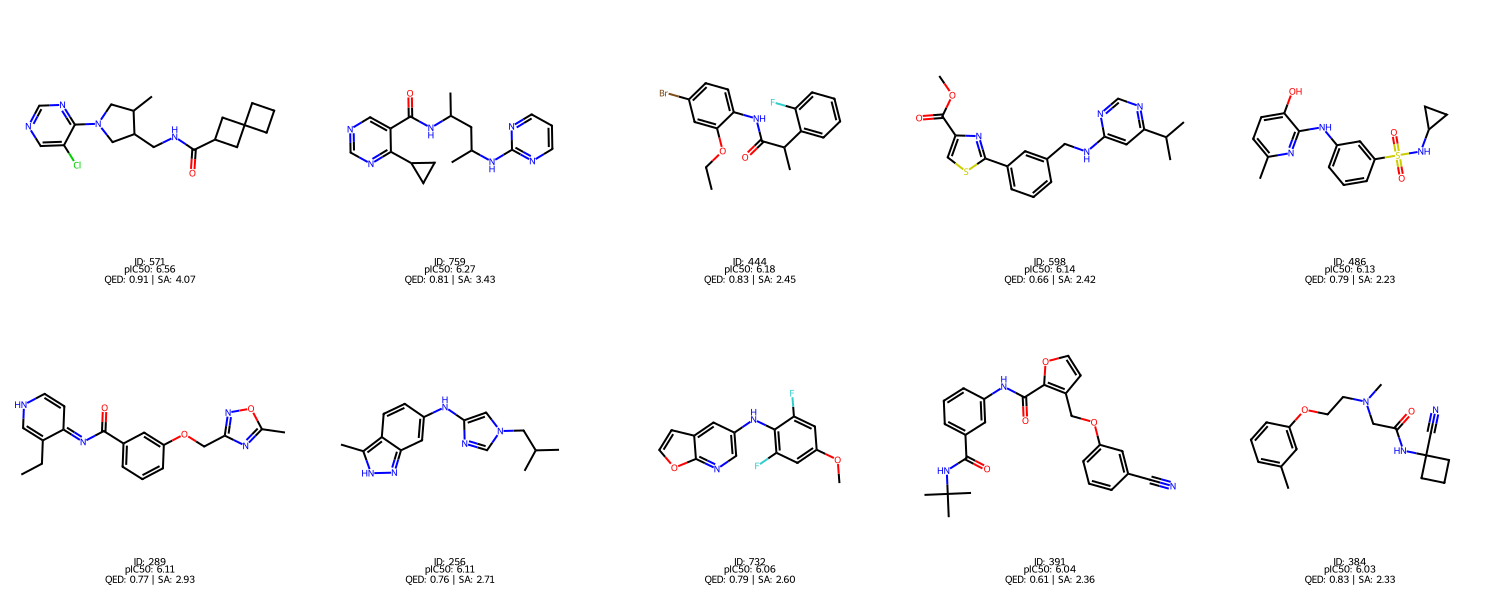

In [106]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

top_candidates = valid_df.sort_values("pIC50_EGFR", ascending=False).head(10)

mols = top_candidates['MOL'].tolist()
legends = []

for i, row in top_candidates.iterrows():
    legend = (f"ID: {i}\n\n"
              f"pIC50: {row['pIC50_EGFR']:.2f}\n\n"
              f"QED: {row['QED']:.2f} | SA: {row['SA']:.2f}")
    legends.append(legend)

draw_opts = Draw.MolDrawOptions()
draw_opts.clearBackground = True
draw_opts.backgroundColour = (1, 1, 1, 1)

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=5,
    subImgSize=(300, 300),
    legends=legends,
    drawOptions=draw_opts,
    useSVG=False
)
img